# BasicPytorchGAN  
Andrew E. Davidson aedavids@ucsc.edu 8/29/24  

Copyright (c) 2020-2023, Regents of the University of California All rights reserved.   https://polyformproject.org/licenses/noncommercial/1.0.0

AIM: create a simple GAN that is easy to test our basic framework

generate y = x^2

ref: 
- chapter 6. in Generative Advisarial Networks with Python  
    this does not work. Keras/tensor flow version issues?  
    re-write example using pytorch

- [pytorch doc](https://pytorch.org/docs/stable/index.html)

installed following to get rid of warning
```
https://ipywidgets.readthedocs.io/en/stable/user_install.html
conda install -c conda-forge jupyterlab_widgets
conda install -c conda-forge ipywidgets

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
```

In [1]:
import ipynbname
import matplotlib.pyplot as plt

from numpy import hstack
from numpy import zeros
from numpy import ones
import psutil # provides process stats
from numpy.random import rand
from numpy.random import randn
import os

# by default keras use tensorflow as backend
import torch
print(f'torch.__version__: {torch.__version__}')

from torch import nn
torch.manual_seed(0) # Set for testing purposes, please do not change!

# tqdm provides progress bars for loops and iterables.
from tqdm.auto import tqdm

# class that helps you efficiently load and iterate over your dataset
# during training or inference
# we do not need this for our toy example
from torch.utils.data import DataLoader

notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True) 
print(f'imgOut:\n{imgOut}')

torch.__version__: 2.5.1.post102
imgOut:
/private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img


## Create models

In [2]:
class ParabolaGenerator( nn.Module ):
    def __init__( self, latentDim : int, nOutputs : int = 2 ) :
        '''
        arguments:
            latentDim: the length of the noise input vector

            nOutputs : the length of the output layers vector. Default = 2
        '''
        super().__init__()


        # keras
        # model.add(Dense(15, activation='relu', kernel_initializer='he_uniform', input_dim=latent_dim))
        # model.add(Dense(n_outputs, activation='linear'))
        
        self.model = nn.Sequential(
            nn.Linear(latentDim, 15),
            nn.ReLU(),
            nn.Linear(15, nOutputs),
        )
        # Initialize weights
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)
        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='linear')
        nn.init.zeros_(self.model[2].bias)

    def forward( self, noise : torch.Tensor ):
        '''
            noise should be the value returned by generateLatentPoints()
        '''
        ret = self.model( noise )
        return ret

In [3]:
class ParabolaDiscriminator( nn.Module ):
    def __init__( self, inputSize : int = 2 ):
        '''
            inputSize, the length of the generated vectors
        '''
        super().__init__()

        # keras
        # model = Sequential()
    	# model.add(Dense(25, activation='relu', kernel_initializer='he_uniform', input_dim=n_inputs))
    	# model.add(Dense(1, activation='sigmoid'))
        
        self.model = nn.Sequential(
            nn.Linear(inputSize, 25),
            nn.ReLU(),
            nn.Linear(25, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)
        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='sigmoid')
        nn.init.zeros_(self.model[2].bias)

    def forward( self, X : torch.Tensor ):
        ret = self.model( X )
        return ret

def testParabolaDiscriminator() :
    inputSize = 2
    discriminator = ParabolaDiscriminator( inputSize )
    numTest = 2
    testInput = torch.randn( numTest, inputSize )
    predictions = discriminator( testInput )
    print(f'\npredictions :\n{predictions}')

testParabolaDiscriminator()


predictions :
tensor([[0.5380],
        [0.5828]], grad_fn=<SigmoidBackward0>)


## Data Utilities
function to generate real and fake tensors

In [4]:
def generateRealSamples( n : int, device : str = 'cpu' ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    generate n real parabola samples with class labels

    arguments :
        n : number of examples to generated

        device. either 'cpu' or 'cuda', default 'cpu'

    Returns 2 Tensor
        X, y i.e. (realSamples, realLabels)

        y = 1, ie real
    '''
    # generate inputs in range [-0.5, 0.5]
    X1 = rand(n) - 0.5
    
    # generate outputs X^2
    X2 = X1 * X1
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    X = hstack((X1, X2))
    
    # generate class labels
    y = ones((n, 1))

    # numpy dtype defaults to float64
    # pytorch default is float32
    realSamples = torch.tensor( X, dtype=torch.float32 ).to( device )
    realLabels = torch.tensor( y, dtype=torch.float32 ).to( device )
    
    return (realSamples, realLabels)

def testGenerateRealSamples() :
    X, y = generateRealSamples( n = 5 ) 
    print(f'X.device : {str(X.device)}')
    print( f'X.shape: {X.shape} rank : {len(X.shape)} num elements : {X.numel()}' )
    print( X )

    print(f'\ny.device : {str(y.device)}')
    print( f'y.shape: {y.shape} rank : {len(y.shape)} num elements : {y.numel()}' )
    print ( y) 

testGenerateRealSamples()

X.device : cpu
X.shape: torch.Size([5, 2]) rank : 2 num elements : 10
tensor([[1.4090e-02, 1.9854e-04],
        [2.2943e-02, 5.2638e-04],
        [1.7207e-01, 2.9607e-02],
        [3.8692e-01, 1.4971e-01],
        [4.7136e-01, 2.2218e-01]])

y.device : cpu
y.shape: torch.Size([5, 1]) rank : 2 num elements : 5
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [5]:
def generateLatentPoints(latentDimensions : int = 5, 
                         n : int = 100, device : str = 'cpu' ) -> torch.Tensor :
    '''
    generate points in latent space as input for the generator

    latentDimensions:
        the number of dimensions for the generator's input vector

    n the number of vectors to generate

    device. either 'cpu' or 'cuda', default 'cpu'


    returns a tensor
    '''
    # generate points in the latent space
    xInput = randn(latentDimensions * n)
    
    # reshape into a batch of inputs for the network
    xInput = xInput.reshape(n, latentDimensions)
    
    ret = torch.Tensor( xInput ).to( device )
    
    return ret

def testGenerateLatentPoints():
    tglp = generateLatentPoints(latentDimensions=5, n=3 )
    print(f'tglp.device : {str(tglp.device)}')
    print( tglp )
    print( tglp.shape )

testGenerateLatentPoints()

tglp.device : cpu
tensor([[ 0.4476, -1.2907, -2.0334,  0.0965, -1.6827],
        [-0.7765, -0.4391, -1.2555, -0.1164,  0.6501],
        [-0.6476,  1.8331,  0.3050,  0.2152,  1.4095]])
torch.Size([3, 5])


In [6]:
def generateFakeSamples(generator : ParabolaGenerator, 
                        latentDimensions : int,
                        n : int,
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor]:
    '''
    use the generator to generate n fake examples, with class labels

    gradient calculation is disabled. (should run faster)

    device. either 'cpu' or 'cuda', default 'cpu'


    returns (fakeSamples, fakeLabels)
        labels will be zeros.
    '''
    # generate points in latent space
    noiseVector = generateLatentPoints(latentDimensions, n)

    # Set the model to evaluation mode
    # Layers like Dropout and Batch Normalization behave differently during 
    # training and evaluation.
    #
    # we do not need to worry about this. It a good future proofing code example
    generator.eval()

    # Disable gradient calculation for inference
    with torch.no_grad():
        fakeSamples = generator(noiseVector)
    
    # create class labels  
    y = zeros((n, 1))
    fakeLabels = torch.Tensor( y ).to( device )
    
    return fakeSamples, fakeLabels

def testGenerateFakeSamples():
    latentDimensions = 5
    numOutputs = 2
    

    gen = ParabolaGenerator( latentDimensions, numOutputs )

    numSamples = 3
    fakeSamples, fakeLabels = generateFakeSamples( gen, latentDimensions, numSamples)

    print( f'\nfakeSamples.shape: {fakeSamples.shape} rank : {len(fakeSamples.shape)} num elements : {fakeSamples.numel()}' )
    print(f'fakeSamples.device : {str(fakeSamples.device)}')

    print( fakeSamples )

    print( f'\nfakeLabels.shape: {fakeLabels.shape} rank : {len(fakeLabels.shape)} num elements : {fakeLabels.numel()}' )
    print(f'fakeLabels.device : {str(fakeLabels.device)}')
    
    print ( fakeLabels ) 


testGenerateFakeSamples()


fakeSamples.shape: torch.Size([3, 2]) rank : 2 num elements : 6
fakeSamples.device : cpu
tensor([[ 1.4456,  0.4246],
        [ 1.0958, -0.6495],
        [ 2.6173,  1.8118]])

fakeLabels.shape: torch.Size([3, 1]) rank : 2 num elements : 3
fakeLabels.device : cpu
tensor([[0.],
        [0.],
        [0.]])


## Train Model

In [7]:
def getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
                         n, zDim, device) -> torch.Tensor:
    '''
    Return the loss of the discriminator on real and fake samples.
    
    Parameters:
        generator: the generator model, which returns an image given z-dimensional noise
        
        discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
        criterion: the loss function, which should be used to compare 
               the discriminator's predictions to the ground truth reality of the images 
               (e.g. fake = 0, real = 1)
               
        real: a batch of real samples
        
        n: the number of fakes the generator should produce, 
                which is also the length of the real images
                
        zDim: the dimension of the noise vector, a scalar
        
        device: the device type
        
    Returns:
        discriminatorLoss: a torch scalar loss value for the current batch
    '''
    # generate some fake samples
    fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, n, device )

    # get discriminator's prediction of the fake samples
    # forward
    predictionsOnFakes = discriminator( fakeSamples )
    
    # calculate the loss on fakes
    expected = torch.zeros(n, 1, device=device)  # All weights are equal to 0, ie fake
    discriminatorLossOnFake = criterion(predictionsOnFakes, expected) 
   
    # calculate loss on real samples
    predictionsOnReal = discriminator( realSamples )
    expected = torch.ones(n, 1, device=device)  # All weights are equal to 1, ie real
    discriminatorLossOnReal = criterion(predictionsOnReal, expected) 
   
    # calculate the average loss
    discriminatorLoss = (discriminatorLossOnReal + discriminatorLossOnFake) / 2
    
    return discriminatorLoss

In [8]:
def testGetDiscriminatorLossSample() :
    zDim = 5 # length of noise vector
    exampleLength = 2 # X,Y
    device = 'cpu'
    batchSize = 4

    generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
    discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
    criterion = nn.BCEWithLogitsLoss()

    realSamples, realLabels = generateRealSamples( batchSize, device )
    
    discriminatorLoss = getDiscriminatorLoss(generator, discriminator, criterion, 
                                             realSamples, batchSize,
                                              zDim, device)

    print( f'discriminator loss : {discriminatorLoss}') 

testGetDiscriminatorLossSample()

discriminator loss : 0.6996166110038757


In [9]:
def getGeneratorLoss(generator, discriminator, criterion, 
                     n, zDim, device) -> torch.Tensor:
    '''
    The generator never sees real samples. Loss is
    calculated only on fake samples

        Parameters:
        generator: the generator model, which returns an image given z-dimensional noise
        
        discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
        criterion: the loss function, which should be used to compare 
               the discriminator's predictions to the ground truth reality of the images 
               (e.g. fake = 0, real = 1)
               
        n: the number of fakes the generator should produce, 
                
        zDim: the dimension of the noise vector, a scalar
        
        device: the device type
        
    Returns:
        generatorLoss: a torch scalar loss value for the current batch
    '''
    noiseVector = generateLatentPoints(zDim, n, device)

    # forward() is the old way of doing things it breaks the grader
    #fakeImgs = gen.forward(noiseVector)
    fakeSamples = generator(noiseVector)
    
    # forward() is the old way of doing things     
    # predictionsOnFake = disc.forward( fakeImgs ).detach()
    predictionsOnFake = discriminator( fakeSamples )#.detach()
    
    # we are trying to trick the discriminator into thinking
    # the fakes are real
    expected = torch.ones(n, 1, device=device)  
    generatorLoss = criterion(predictionsOnFake, expected) 
    #     print(f'\nAEDWIP type(generatorLoss): {type(generatorLoss)}')
    #     print(f'AEDWIP generatorLoss.shape: {generatorLoss.shape}')
    #     print(f'AEDWIP generatorLoss: {generatorLoss}')   

    return generatorLoss

In [10]:
def testGetGeneratorLoss():
    zDim = 5 # length of noise vector
    n = 4 # number of fakes to generate  
    exampleLength = 2 # X,Y
    device = 'cpu'    
    
    generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
    discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device)     
    criterion = nn.BCEWithLogitsLoss()

    generatorLoss = getGeneratorLoss(generator, discriminator, criterion, n, zDim, device) 
    print(f'generatorLoss.shape : {generatorLoss.shape}')
    print(f'generatorLoss\n{generatorLoss}')
    
testGetGeneratorLoss()    

generatorLoss.shape : torch.Size([])
generatorLoss
0.4881454110145569


In [11]:
# def summarizePerformance(epoch, generator, discriminator, latentDim, n=100):
def summarizePerformance( generator : ParabolaGenerator, 
                         latentDimensions : int,
                         outDir : str,
                        title : str):
    n = 100
    realSamples, realLabels = generateRealSamples( n )
    fakeSamples, fakeLabels = generateFakeSamples( generator, latentDimensions, n)
    
    #    # evaluate discriminator on real examples
    # _, acc_real = discriminator.evaluate(xReal, yReal)
    # # prepare fake examples
    # x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    # # evaluate discriminator on fake examples
    # _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    # # summarize discriminator performance
    # print(epoch, acc_real, acc_fake)
    # scatter plot real and fake data points
    
    # parabola y = x^2, first column = x, second column = y
    plt.scatter(realSamples[:, 0], realSamples[:, 1], color='red')
    plt.scatter(fakeSamples[:, 0], fakeSamples[:, 1], color='blue')

    fig = plt.gcf()
    fig.suptitle(title)

    # save plot to file
    fileName = f'{outDir}/generated_plot_epoch{epoch+1:03d}.png'
    print(f'saved : {fileName}')
    plt.savefig(fileName)
    plt.show()
    plt.close()

In [12]:
# Set your parameters
criterion = nn.BCEWithLogitsLoss()
nEpochs = 1000 #600 #500 #200
numBatchs = 200 #100 #50 # number of batchs per epoch
zDim = 5 # length of noise vector
displayStep = 10000 #1000 #500 #200 # 500
batchSize = 128
lr = 0.00001
exampleLength = 2 # X,Y
#device = 'cuda'
device = 'cpu'
plotStep = displayStep #4000 #2000 

generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)
generatorOptimizer = torch.optim.Adam(generator.parameters(), lr=lr)

discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
discriminatorOptimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch050.png


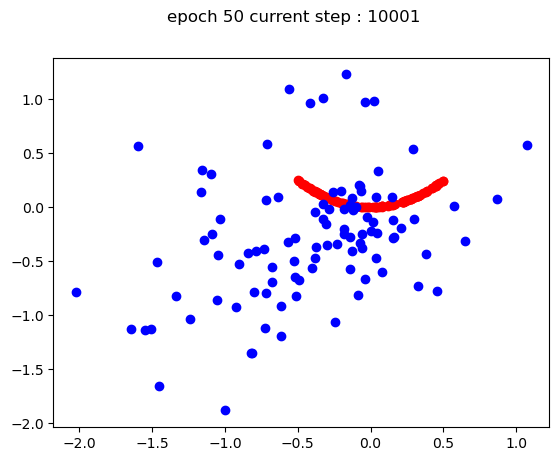

Step 10000: Generator loss: 0.7043793388426307, discriminator loss: 0.5079700386375199
Memory usage (RSS): 353.1796875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch100.png


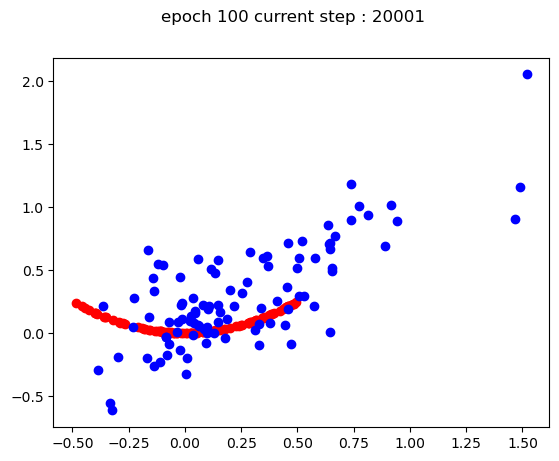

Step 20000: Generator loss: 1.405261698216199, discriminator loss: 1.0425039804428797
Memory usage (RSS): 353.53125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch150.png


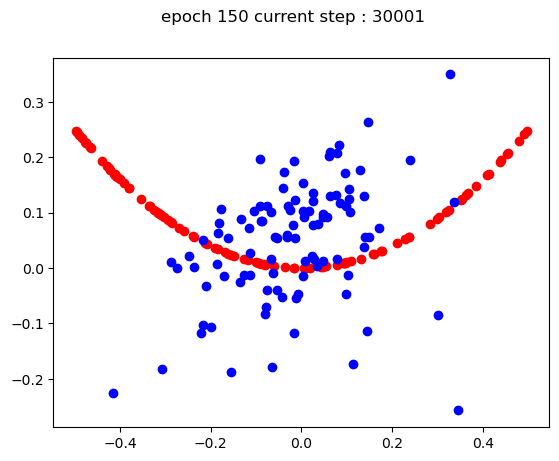

Step 30000: Generator loss: 2.1067030684709525, discriminator loss: 1.6007149349242404
Memory usage (RSS): 356.5546875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch200.png


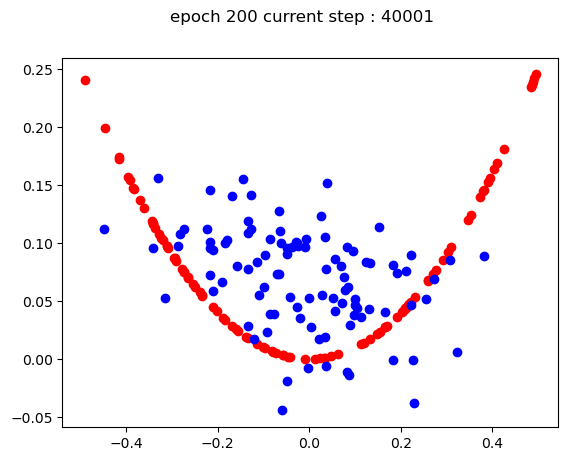

Step 40000: Generator loss: 2.805475607520344, discriminator loss: 2.1996059033900512
Memory usage (RSS): 356.83984375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch250.png


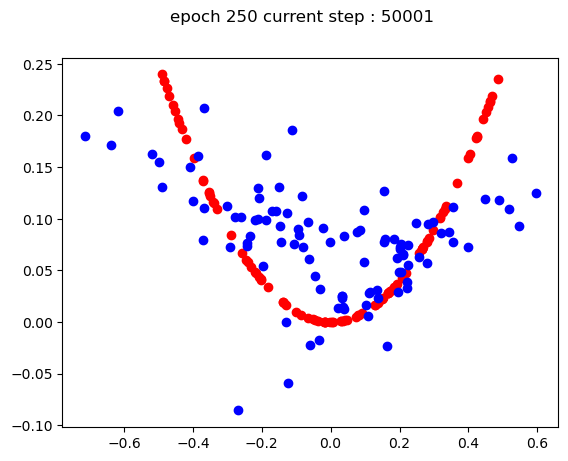

Step 50000: Generator loss: 3.4996308116018726, discriminator loss: 2.8419300272375385
Memory usage (RSS): 358.671875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch300.png


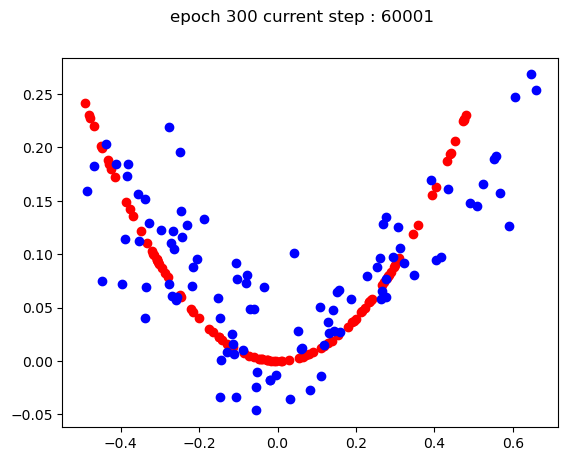

Step 60000: Generator loss: 4.19278300790191, discriminator loss: 3.5089202406078663
Memory usage (RSS): 358.7265625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch350.png


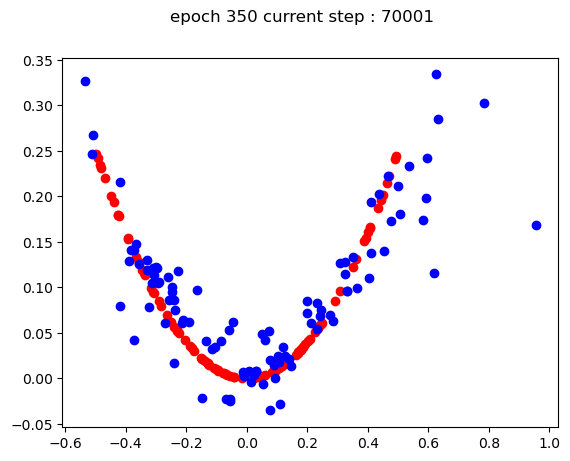

Step 70000: Generator loss: 4.885865944355729, discriminator loss: 4.186834769198315
Memory usage (RSS): 360.58984375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch400.png


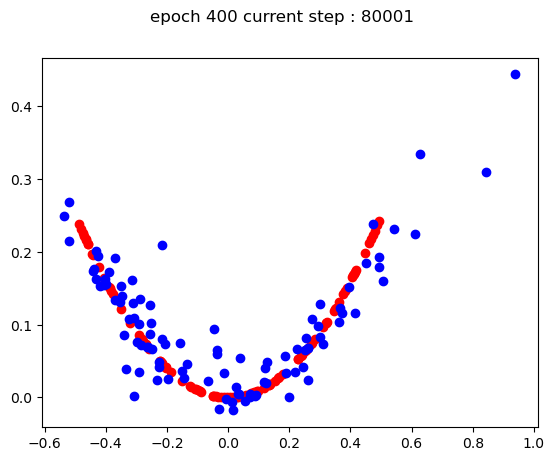

Step 80000: Generator loss: 5.578948774963616, discriminator loss: 4.868178204950704
Memory usage (RSS): 362.4140625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch450.png


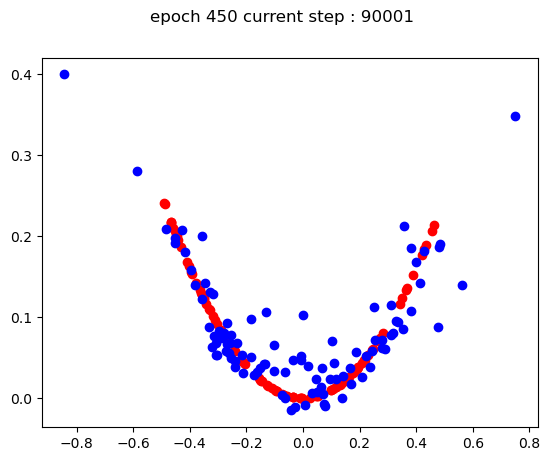

Step 90000: Generator loss: 6.272046770960107, discriminator loss: 5.5509715135008095
Memory usage (RSS): 362.828125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch500.png


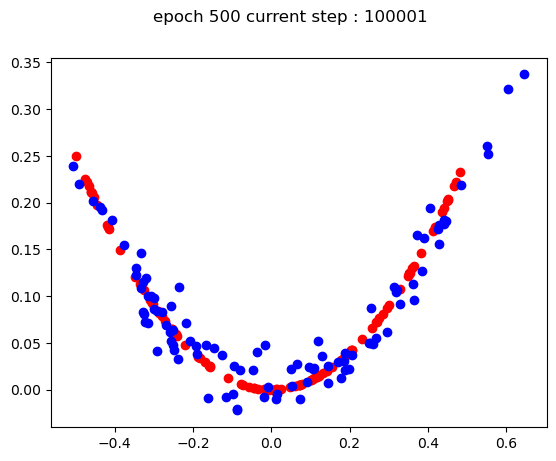

Step 100000: Generator loss: 6.965162218332279, discriminator loss: 6.2354322784930325
Memory usage (RSS): 364.2734375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch550.png


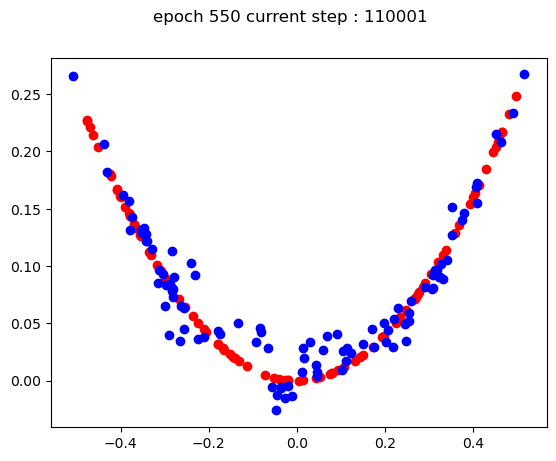

Step 110000: Generator loss: 7.658290486842375, discriminator loss: 6.921593057379086
Memory usage (RSS): 364.5390625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch600.png


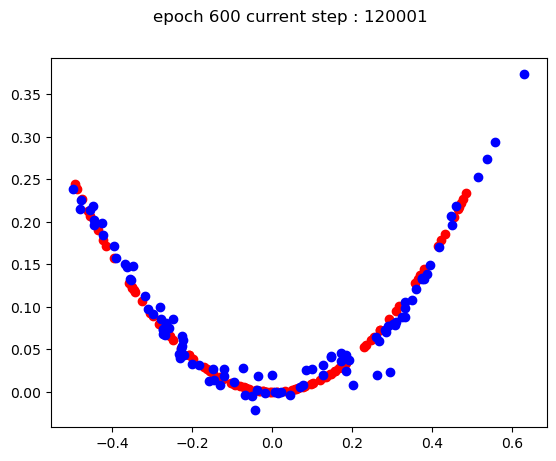

Step 120000: Generator loss: 8.351425442642045, discriminator loss: 7.609210949346391
Memory usage (RSS): 364.5234375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch650.png


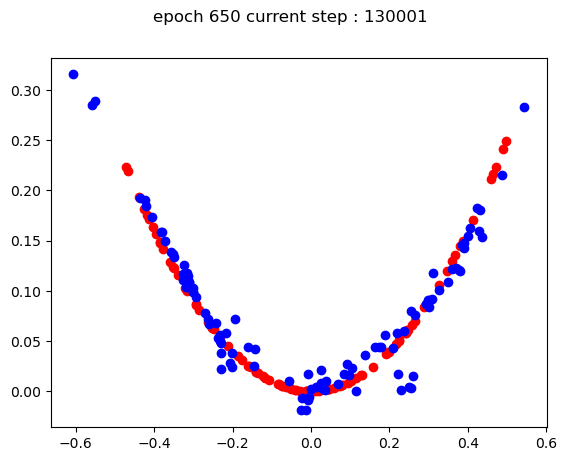

Step 130000: Generator loss: 9.044562673270901, discriminator loss: 8.29772233863173
Memory usage (RSS): 364.5 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch700.png


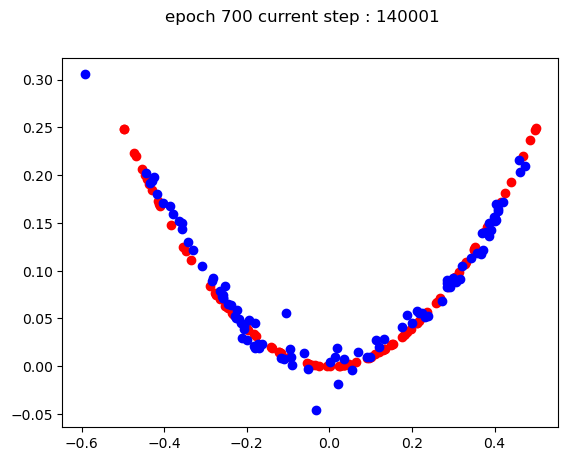

Step 140000: Generator loss: 9.737699425262463, discriminator loss: 8.986473943224587
Memory usage (RSS): 364.49609375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch750.png


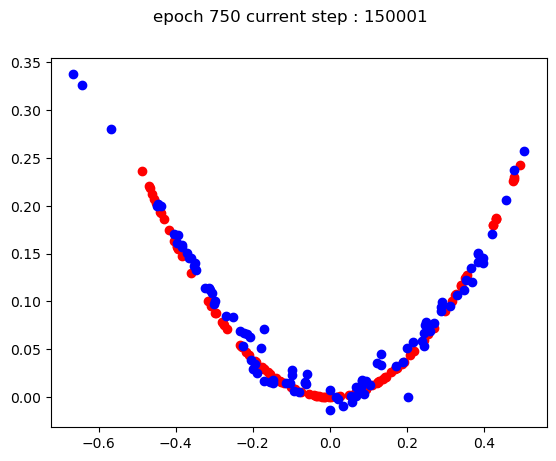

Step 150000: Generator loss: 10.430833726865426, discriminator loss: 9.674925686088235
Memory usage (RSS): 364.47265625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch800.png


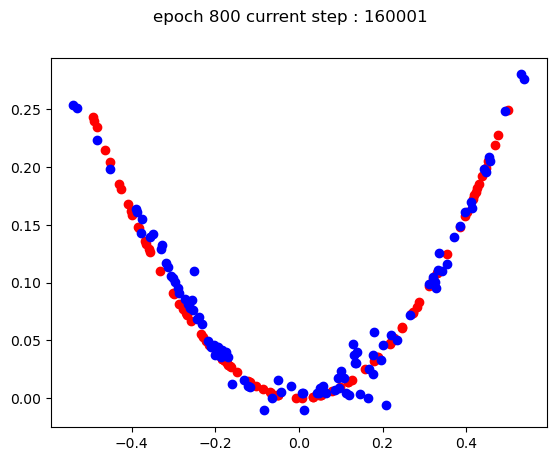

Step 160000: Generator loss: 11.123966042441616, discriminator loss: 10.362939198228764
Memory usage (RSS): 364.453125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch850.png


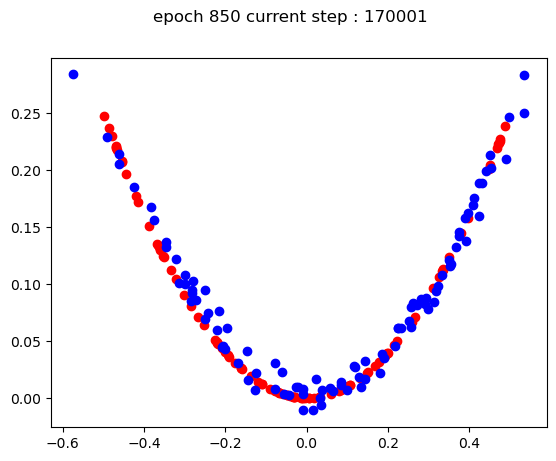

Step 170000: Generator loss: 11.817096742165575, discriminator loss: 11.050631835892911
Memory usage (RSS): 364.44921875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch900.png


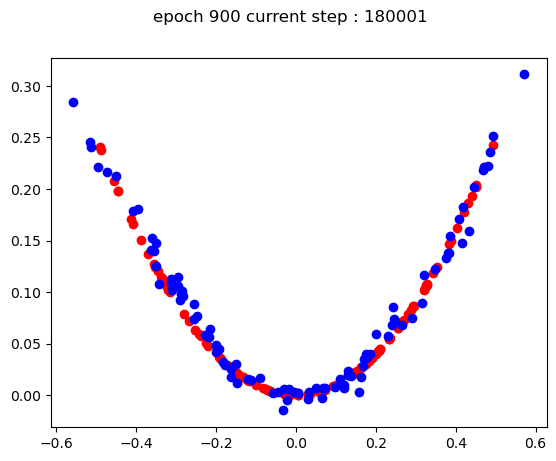

Step 180000: Generator loss: 12.510225852030912, discriminator loss: 11.738084551414955
Memory usage (RSS): 364.44921875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch950.png


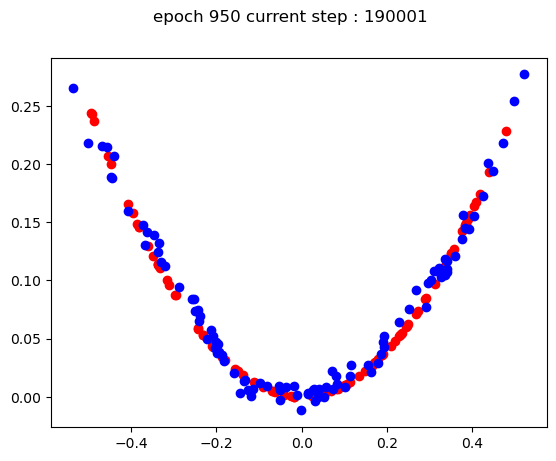

Step 190000: Generator loss: 13.203353528965055, discriminator loss: 12.425288763263893
Memory usage (RSS): 364.44140625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch1000.png


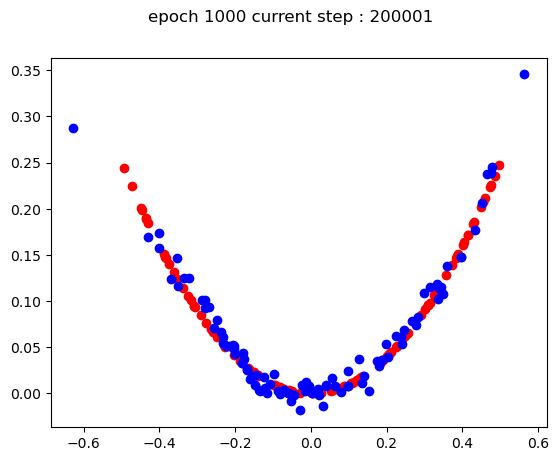

finished
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/basicPytorchGAN.out/img/generated_plot_epoch1000.png


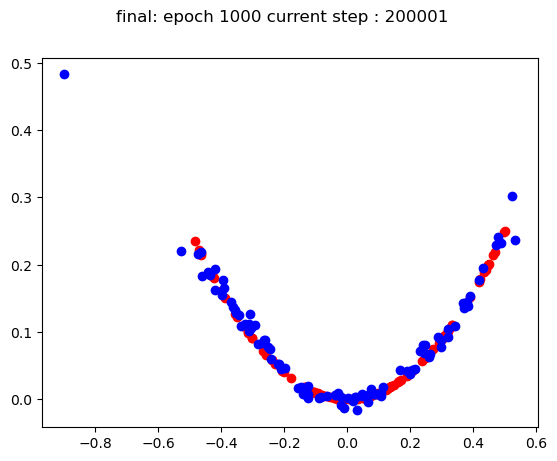

Step 200000: Generator loss: 13.896410181808955, discriminator loss: 13.112198923072295
CPU times: user 16h 47min 23s, sys: 1h 5min 19s, total: 17h 52min 42s
Wall time: 13min 27s


In [13]:
%%time

# reset state every time we run
currentStep = 0
meanGeneratorLoss = 0
meanDiscriminatorLoss = 0
testGenerator = True # Whether the generator should be tested
genLoss = False
error = False


for epoch in range(nEpochs):
    # print(f'epoch: {epoch}')    
    
    # tqdm provides progress bars for loops and iterables.
    # will choose implementaiton based on env. ie shell, juypter, ...
    # https://tqdm.github.io/
    # for i in tqdm( range(numBatchs) ) : 
    for i in range(numBatchs) : 
        # if we where working with real data it is possible 
        # some batches are short. are < batchSize
        currentBatchSize = batchSize
        realSamples, realLabels = generateRealSamples( currentBatchSize )
        
        #
        # Update discriminator 
        #
        
        # Zero out the gradients before backpropagation
        discriminatorOptimizer.zero_grad()
        
        # Calculate discriminator loss
        discLoss = getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
                                  currentBatchSize, zDim, device)
        
        # Update gradients
        discLoss.backward(retain_graph=True)
        
        # Update optimizer
        discriminatorOptimizer.step()

        #
        # update generator
        #

        # For testing purposes, to keep track of the generator weights
        if testGenerator:
            # our last layer is a linear label not a list of layers
            #oldGeneratorWeights = generator.model[0][0].weight.detach().clone()
            oldGeneratorWeights = generator.model[0].weight.detach().clone()

        generatorOptimizer.zero_grad()
        generatorLoss = getGeneratorLoss(generator, discriminator, criterion, 
                                         currentBatchSize, zDim, device)
        generatorLoss.backward(retain_graph=True)
        generatorOptimizer.step()

        #
        # For testing purposes, to check that your code changes the generator weights
        #
        if testGenerator:
            try:
                # assert lr > 0.0000002 or (gen.gen[0][0].weight.grad.abs().max() < 0.0005 and epoch == 0)
                xxx = generator.model[0].weight.grad.abs().max()
                # print(f'AEDWIP xxx : {xxx}')
                errMsg = f'assertion failed condition : {xxx}'
                assert (lr > 0.0000002 or xxx < 0.0005 and epoch == 0), errMsg

                
                #assert torch.any(gen.gen[0][0].weight.detach().clone() != old_generator_weights)
                yyy = generator.model[0].weight.detach().clone()
                # print(f'aedwip yyy : {yyy}')
                # print(f'aedwip old : {oldGeneratorWeights}')
                errMsg = f'weights not equal old'
                assert torch.any(yyy != oldGeneratorWeights), errMsg
            except Exception as e:
                print(f'aedwip e:\n{e}')
                error = True
                print("Runtime tests have failed")

        # Keep track of the average discriminator loss
        meanDiscriminatorLoss += discLoss.item() / displayStep

        # Keep track of the average generator loss
        meanGeneratorLoss += generatorLoss.item() / displayStep

        ### Visualization code ###
        if currentStep % displayStep == 0 and currentStep > 0:
            print(f"Step {currentStep}: Generator loss: {meanDiscriminatorLoss}, discriminator loss: {meanGeneratorLoss}")

            # Get memory usage of the current process in bytes
            process = psutil.Process()
            memory_info = process.memory_info()
            rss_memory = memory_info.rss  # Resident Set Size (physical memory used)
            print("Memory usage (RSS):", rss_memory / (1024 * 1024), "MB")   
            
            #display plot
            
            mean_generator_loss = 0
            mean_discriminator_loss = 0
            
        currentStep += 1

        
        #if (epoch + 1) % displayQuotient == 0 and currentStep > 0:
        if currentStep % plotStep == 0 and currentStep > 0:
            title = f"epoch {epoch + 1} current step : {currentStep + 1}"
            summarizePerformance(generator, zDim, imgOut, title)

print(f'finished')
title = f"final: epoch {epoch + 1} current step : {currentStep + 1}"
summarizePerformance(generator, zDim, imgOut, title)
print(f"Step {currentStep}: Generator loss: {meanDiscriminatorLoss}, discriminator loss: {meanGeneratorLoss}")
